In [1]:
# %pip install torch torch-geometric numpy pandas scikit-learn matplotlib streamlit networkx tqdm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

## Pre-Processing

In [3]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

train_df = pd.read_csv("KDDTrain+.txt", names=columns)
test_df  = pd.read_csv("KDDTest+.txt", names=columns)


In [4]:
train_df["binary_label"] = train_df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df["binary_label"] = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)

In [5]:
train_normal = train_df[train_df["binary_label"] == 0].reset_index(drop=True)

print("Training samples (normal only):", train_normal.shape)
print("Testing samples (normal + attacks):", test_df.shape)

Training samples (normal only): (67343, 44)
Testing samples (normal + attacks): (22544, 44)


In [6]:
train_normal["host"] = "host_" + train_normal.index.astype(str)
test_df["host"] = "host_" + test_df.index.astype(str)

train_normal["service_node"] = (train_normal["protocol_type"] + "_" + train_normal["service"])
test_df["service_node"] = (test_df["protocol_type"] + "_" + test_df["service"])

## Graph Construction

In [7]:
import networkx as nx

def build_bipartite_graph(df):
    G = nx.Graph()

    for _, row in df.iterrows():
        host = row["host"]
        service = row["service_node"]

        # Add nodes with bipartite labels
        G.add_node(host, node_type="host")
        G.add_node(service, node_type="service")

        # Add / update edge
        if G.has_edge(host, service):
            G[host][service]["weight"] += 1
        else:
            G.add_edge(host, service, weight=1)

    return G

In [8]:
G_train = build_bipartite_graph(train_normal)

print("Training Graph")
print("Nodes:", G_train.number_of_nodes())
print("Edges:", G_train.number_of_edges())

Training Graph
Nodes: 67371
Edges: 67343


In [9]:
G_test = build_bipartite_graph(test_df)

print("Test Graph")
print("Nodes:", G_test.number_of_nodes())
print("Edges:", G_test.number_of_edges())

Test Graph
Nodes: 22610
Edges: 22544


In [10]:
# Count host and service nodes
hosts = [n for n, d in G_train.nodes(data=True) if d["node_type"] == "host"]
services = [n for n, d in G_train.nodes(data=True) if d["node_type"] == "service"]

print("Hosts:", len(hosts))
print("Services:", len(services))

Hosts: 67343
Services: 28


In [11]:

# Separate node sets
hosts = [n for n, d in G_train.nodes(data=True) if d["node_type"] == "host"]
services = [n for n, d in G_train.nodes(data=True) if d["node_type"] == "service"]

# Sample nodes
sample_hosts = random.sample(hosts, 50)
sample_services = services  # only 28, safe to show

# Induced subgraph
sample_nodes = sample_hosts + sample_services
G_sample = G_train.subgraph(sample_nodes)

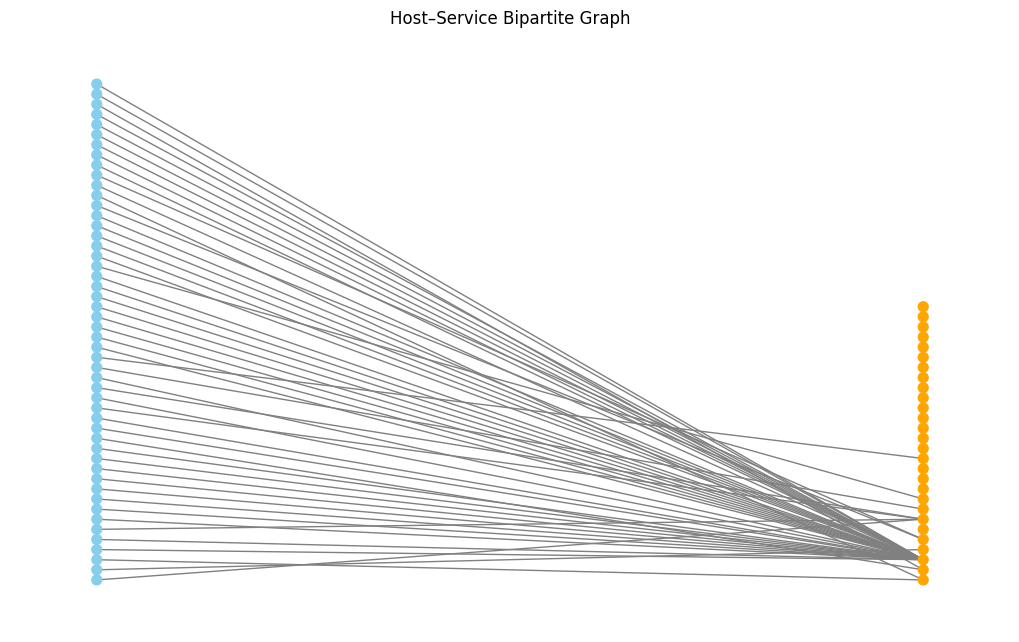

In [12]:
pos = {}

# Place hosts on the left
for i, node in enumerate(sample_hosts):
    pos[node] = (0, i)

# Place services on the right
for i, node in enumerate(sample_services):
    pos[node] = (1, i)

plt.figure(figsize=(10, 6))
nx.draw(
    G_sample,
    pos,
    with_labels=False,
    node_size=50,
    node_color=["skyblue" if G_sample.nodes[n]["node_type"]=="host" else "orange"
                for n in G_sample.nodes()],
    edge_color="gray"
)

plt.title("Host–Service Bipartite Graph")
plt.show()

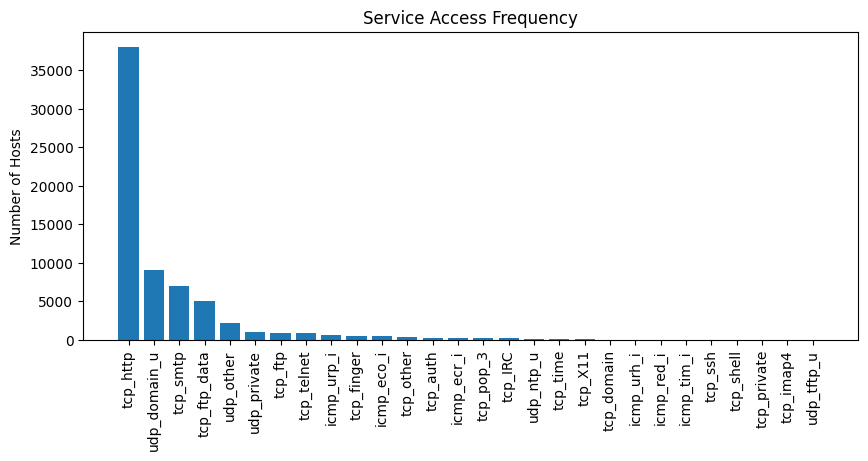

In [13]:
service_degrees = [(s, G_train.degree(s)) for s in services]
service_degrees.sort(key=lambda x: x[1], reverse=True)

labels = [x[0] for x in service_degrees]
values = [x[1] for x in service_degrees]

plt.figure(figsize=(10,4))
plt.bar(labels, values)
plt.xticks(rotation=90)
plt.ylabel("Number of Hosts")
plt.title("Service Access Frequency")
plt.show()

## Feature Extraction

### Host

In [14]:
def extract_host_features(G):
    host_features = {}

    for node, data in G.nodes(data=True):
        if data["node_type"] != "host":
            continue

        neighbors = list(G.neighbors(node))
        degrees = len(neighbors)

        # Edge weights (interaction frequency)
        weights = np.array([G[node][nbr]["weight"] for nbr in neighbors])

        total_interactions = weights.sum()
        avg_interaction = weights.mean() if degrees > 0 else 0

        # Entropy of service usage (important for probe attacks)
        probs = weights / total_interactions if total_interactions > 0 else np.zeros_like(weights)
        entropy = -np.sum(probs * np.log2(probs + 1e-9))

        host_features[node] = [
            degrees,
            total_interactions,
            avg_interaction,
            entropy
        ]

    return host_features


# [degree, total_interactions, avg_interaction, entropy]

### Service

In [15]:
def extract_service_features(G):
    service_features = {}

    for node, data in G.nodes(data=True):
        if data["node_type"] != "service":
            continue

        neighbors = list(G.neighbors(node))
        degrees = len(neighbors)

        weights = np.array([G[node][nbr]["weight"] for nbr in neighbors])
        total_access = weights.sum()
        avg_access = weights.mean() if degrees > 0 else 0

        service_features[node] = [
            degrees,
            total_access,
            avg_access
        ]

    return service_features


# [number_of_hosts, total_access, avg_access]

### Edge

In [16]:
def extract_edge_features(G):
    edge_features = {}

    weights = np.array([d["weight"] for _, _, d in G.edges(data=True)])
    max_weight = weights.max() if len(weights) > 0 else 1

    for u, v, d in G.edges(data=True):
        edge_features[(u, v)] = [
            d["weight"],
            d["weight"] / max_weight
        ]

    return edge_features


# [interaction_frequency, normalized_frequency]

### Training Graph

In [17]:
host_feats_train = extract_host_features(G_train)
service_feats_train = extract_service_features(G_train)
edge_feats_train = extract_edge_features(G_train)

print("Host feature shape:", len(next(iter(host_feats_train.values()))))
print("Service feature shape:", len(next(iter(service_feats_train.values()))))
print("Edge feature shape:", len(next(iter(edge_feats_train.values()))))

Host feature shape: 4
Service feature shape: 3
Edge feature shape: 2


### Testing Graph

In [18]:
host_feats_train = extract_host_features(G_train)
service_feats_train = extract_service_features(G_train)
edge_feats_train = extract_edge_features(G_train)

print("Host feature shape:", len(next(iter(host_feats_train.values()))))
print("Service feature shape:", len(next(iter(service_feats_train.values()))))
print("Edge feature shape:", len(next(iter(edge_feats_train.values()))))


Host feature shape: 4
Service feature shape: 3
Edge feature shape: 2


## NetworkX Graph → PyTorch Geometric

In [19]:
import torch
print(torch.__version__)

2.10.0+cpu


In [20]:
import torch
torch.__version__, torch.version.cuda

('2.10.0+cpu', None)

In [ ]:
# pip install torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cpu.html

Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
# pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric

In [23]:
import torch_geometric
print(torch_geometric.__version__)

c:\Users\Kirthick\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.7.0


In [24]:
from torch_geometric.data import Data

### Node Index Mapping

In [25]:
# Nodes → Indices

def create_node_mapping(G):
    node_list = list(G.nodes())
    node_to_idx = {node: i for i, node in enumerate(node_list)}
    idx_to_node = {i: node for node, i in node_to_idx.items()}
    return node_to_idx, idx_to_node

node_to_idx_train, idx_to_node_train = create_node_mapping(G_train)

### Edge Index Tensor

In [26]:
def build_edge_index(G, node_to_idx):
    edge_index = []

    for u, v in G.edges():
        edge_index.append([node_to_idx[u], node_to_idx[v]])
        edge_index.append([node_to_idx[v], node_to_idx[u]])  # undirected

    return torch.tensor(edge_index, dtype=torch.long).t()

edge_index_train = build_edge_index(G_train, node_to_idx_train)

### Node Feature Matrix

In [27]:
def build_node_features(G, node_to_idx, host_feats, service_feats):
    num_nodes = len(node_to_idx)
    feature_dim = 4  # max(host=4, service=3)

    X = torch.zeros((num_nodes, feature_dim), dtype=torch.float)

    for node, idx in node_to_idx.items():
        if G.nodes[node]["node_type"] == "host":
            X[idx, :] = torch.tensor(host_feats[node], dtype=torch.float)
        else:
            feats = service_feats[node]
            X[idx, :len(feats)] = torch.tensor(feats, dtype=torch.float)

    return X

X_train = build_node_features(
    G_train,
    node_to_idx_train,
    host_feats_train,
    service_feats_train
)

### (Optional) Edge Weight Tensor

In [28]:
def build_edge_weights(G, node_to_idx):
    weights = []

    for u, v in G.edges():
        weights.append(G[u][v]["weight"])
        weights.append(G[u][v]["weight"])  # for reverse edge

    return torch.tensor(weights, dtype=torch.float)

edge_weight_train = build_edge_weights(G_train, node_to_idx_train)

# Normalize using training stats
edge_weight_train = edge_weight_train / edge_weight_train.max()

### PyG Data Object

In [29]:
data_train = Data(
    x=X_train,
    edge_index=edge_index_train,
    edge_weight=edge_weight_train
)

print(data_train)

# Data(x=[N, 4], edge_index=[2, E])

Data(x=[67371, 4], edge_index=[2, 134686], edge_weight=[134686])


### Test Graph

In [30]:
# Feature extraction for TEST graph
host_feats_test = extract_host_features(G_test)
service_feats_test = extract_service_features(G_test)
edge_feats_test = extract_edge_features(G_test)


node_to_idx_test, idx_to_node_test = create_node_mapping(G_test)

edge_index_test = build_edge_index(G_test, node_to_idx_test)

X_test = build_node_features(
    G_test,
    node_to_idx_test,
    host_feats_test,
    service_feats_test
)

edge_weight_test = build_edge_weights(G_test, node_to_idx_test)
edge_weight_test = edge_weight_test / edge_weight_train.max()


data_test = Data(
    x=X_test,
    edge_index=edge_index_test,
    edge_weight=edge_weight_test
)

## Graph Autoencoder using GCN

In [70]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

### GCN Encoder

Takes node features + graph structure

Produces latent embeddings for each node

In [71]:
class GCNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, latent_channels):
        super(GCNEncoder, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, latent_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

### Graph Autoencoder (GAE)
GCN encoder
+
Inner-product decoder

In [72]:
class GraphAutoEncoder(nn.Module):
    def __init__(self, encoder):
        super(GraphAutoEncoder, self).__init__()
        self.encoder = encoder

    def encode(self, x, edge_index):
        return self.encoder(x, edge_index)

    def decode(self, z, edge_index):
        src, dst = edge_index
        return (z[src] * z[dst]).sum(dim=1)  # raw logits

    def forward(self, x, edge_index):
        z = self.encode(x, edge_index)
        recon = self.decode(z, edge_index)
        return z, recon


### Initialize Model

In [73]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

in_channels = data_train.x.shape[1]   # 4
hidden_channels = 16
latent_channels = 8

encoder = GCNEncoder(in_channels, hidden_channels, latent_channels)
model = GraphAutoEncoder(encoder).to(device)

data_train = data_train.to(device)

## Training

### Loss

In [75]:
from torch_geometric.utils import negative_sampling

In [76]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# criterion = nn.MSELoss()
criterion = torch.nn.BCEWithLogitsLoss()

### Train the Autoencoder (NORMAL DATA ONLY)

In [94]:
def train(model, data, epochs=50):
    model.train()

    for epoch in range(epochs):
        optimizer.zero_grad()

        z = model.encode(data.x, data.edge_index)

        # Positive edges
        pos_edge_index = data.edge_index
        pos_pred = model.decode(z, pos_edge_index)
        pos_target = torch.ones(pos_pred.size(0), device=z.device)

        # Negative edges (balanced sampling)
        neg_edge_index = negative_sampling(
            edge_index=data.edge_index,
            num_nodes=data.num_nodes,
            num_neg_samples=pos_edge_index.size(1) // 2
        )

        neg_pred = model.decode(z, neg_edge_index)
        neg_target = torch.zeros(neg_pred.size(0), device=z.device)

        # Combine
        pred = torch.cat([pos_pred, neg_pred])
        target = torch.cat([pos_target, neg_target])

        loss = criterion(pred, target)
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

train(model, data_train, epochs=50)

Epoch 0, Loss: 738.9362
Epoch 10, Loss: 642.1818
Epoch 20, Loss: 546.4694
Epoch 30, Loss: 470.2682
Epoch 40, Loss: 406.6188


In [95]:
torch.save(model.state_dict(), "gcn_autoencoder.pth")

In [39]:
model = GraphAutoEncoder(encoder)
model.load_state_dict(torch.load("gcn_autoencoder.pth"))
model.eval()

GraphAutoEncoder(
  (encoder): GCNEncoder(
    (conv1): GCNConv(4, 16)
    (conv2): GCNConv(16, 8)
  )
)

## Probe Attack Detection

### Compute Node Embeddings on Test Graph

In [125]:
with torch.no_grad():
    z_test = model.encode(data_test.x.to(device), data_test.edge_index.to(device))

### Compute Edge Reconstruction Error

In [126]:
edge_index = data_test.edge_index.to(device)
src, dst = edge_index

edge_logits = (z_test[src] * z_test[dst]).sum(dim=1)
edge_probs = torch.sigmoid(edge_logits)

edge_error = torch.abs(1 - edge_probs)

edge_error

tensor([0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 8.9169e-05, 4.6050e-01,
        4.6050e-01])

### Aggregate Edge Errors → Host-Level Error

In [127]:
import numpy as np

host_error = {}

for i, (u, v) in enumerate(zip(src.cpu().numpy(), dst.cpu().numpy())):
    node_u = idx_to_node_test[u]
    node_v = idx_to_node_test[v]

    # Consider only host → service edges
    if G_test.nodes[node_u]["node_type"] == "host":
        host = node_u
    elif G_test.nodes[node_v]["node_type"] == "host":
        host = node_v
    else:
        continue

    host_error.setdefault(host, []).append(edge_error[i].item())

# Average error per host
host_error_agg = {
    host: np.max(errors) for host, errors in host_error.items()
}

### Set Threshold (NORMAL DATA ONLY)

In [128]:
# Compute training reconstruction error
with torch.no_grad():
    z_train = model.encode(data_train.x.to(device),
                            data_train.edge_index.to(device))

src_t, dst_t = data_train.edge_index.to(device)
edge_logits_t = (z_train[src_t] * z_train[dst_t]).sum(dim=1)
edge_probs_t = torch.sigmoid(edge_logits_t)
edge_error_t = torch.abs(1 - edge_probs_t)

host_error_train = {}

for i, (u, v) in enumerate(zip(src_t.cpu().numpy(), dst_t.cpu().numpy())):
    node_u = idx_to_node_train[u]
    node_v = idx_to_node_train[v]

    if G_train.nodes[node_u]["node_type"] == "host":
        host = node_u
    elif G_train.nodes[node_v]["node_type"] == "host":
        host = node_v
    else:
        continue

    host_error_train.setdefault(host, []).append(edge_error_t[i].item())

host_error_train_avg = np.array([
    np.mean(v) for v in host_error_train.values()
])

threshold = np.percentile(host_error_train_avg, 99)
print("Anomaly Threshold:", threshold)

Anomaly Threshold: 0.0


### Detect Probe Hosts

In [129]:
probe_hosts = [
    host for host, err in host_error_agg.items()
    if err > threshold
]

## Probe Attack Test

In [130]:
probe_attacks = {"ipsweep", "nmap", "portsweep", "satan", "mscan", "saint"}
host_gt_probe = {}

for _, row in test_df.iterrows():
    host = row["host"]
    label = row["label"]

    if label in probe_attacks:
        host_gt_probe[host] = 1
    else:
        host_gt_probe.setdefault(host, 0)


### Prediction Vector

In [131]:
host_pred_probe = {
    host: 1 if host in probe_hosts else 0 for host in host_gt_probe.keys()
}

### Confusion Matrix

In [132]:
TP = FP = TN = FN = 0

for host in host_gt_probe:
    gt = host_gt_probe[host]
    pred = host_pred_probe[host]

    if gt == 1 and pred == 1:
        TP += 1
    elif gt == 0 and pred == 1:
        FP += 1
    elif gt == 0 and pred == 0:
        TN += 1
    elif gt == 1 and pred == 0:
        FN += 1

print("TP:", TP, "FP:", FP, "TN:", TN, "FN:", FN)


TP: 31 FP: 470 TN: 19653 FN: 2390


In [133]:
probe_accuracy  = (TP + TN) / (TP + TN + FP + FN)

print(f"Probe Accuracy : {probe_accuracy:.4f}")

Probe Accuracy : 0.8731


### AUROC

In [134]:
from sklearn.metrics import roc_auc_score

y_true_probe = []
y_scores_probe = []

for host, score in host_error_agg.items():
    y_true_probe.append(host_gt_probe.get(host, 0))
    y_scores_probe.append(score)

probe_auc = roc_auc_score(y_true_probe, y_scores_probe)
print("Probe AUROC:", probe_auc)


Probe AUROC: 0.4947759424931139


## Metrics

In [135]:
# Map host → ground truth label
host_gt = {}

for _, row in test_df.iterrows():
    host = row["host"]
    label = row["binary_label"]  # 1 = attack, 0 = normal

    # If any record is attack, mark host as attack
    host_gt[host] = max(host_gt.get(host, 0), label)


In [136]:
# Predicted labels
host_pred = {}

for host in host_gt.keys():
    host_pred[host] = 1 if host in probe_hosts else 0


In [137]:
TP = FP = TN = FN = 0

for host in host_gt:
    if host_gt[host] == 1 and host_pred[host] == 1:
        TP += 1
    elif host_gt[host] == 0 and host_pred[host] == 1:
        FP += 1
    elif host_gt[host] == 0 and host_pred[host] == 0:
        TN += 1
    elif host_gt[host] == 1 and host_pred[host] == 0:
        FN += 1

print("TP:", TP, "FP:", FP, "TN:", TN, "FN:", FN)


TP: 456 FP: 45 TN: 9666 FN: 12377


In [138]:
accuracy  = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP + 1e-9)
recall    = TP / (TP + FN + 1e-9)     # Detection Rate
fpr       = FP / (FP + TN + 1e-9)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"FPR      : {fpr:.4f}")


Accuracy : 0.4490
Precision: 0.9102
Recall   : 0.0355
FPR      : 0.0046


In [ ]:
from sklearn.metrics import roc_auc_score

y_true = []
y_scores = []

for host, score in host_error_agg.items():
    y_true.append(host_gt.get(host, 0))
    y_scores.append(score)

auc = roc_auc_score(y_true, y_scores)
print("AUROC:", auc)

AUROC: 0.5
